In [2]:
import oqupy
import oqupy.operators as op
import numpy as np
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
from oqupy.tti_tempo import TTITempoCounting
import matplotlib.pyplot as plt


from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize,Bounds

pt_parameters = {'tmax':50,
                 'steps':100, 
                 'dkmax':50,
                 'epsrel':10**(-6),
                 'alpha':0.1,
                 'omega_cutoff':1,                 
                 'temp':0.131}

omega_cutoff = pt_parameters['omega_cutoff']
alpha = pt_parameters['alpha']
temperature = pt_parameters['temp']
epsrel = pt_parameters['epsrel']
t_max = pt_parameters['tmax']
# dt = 1./omega_cutoff/np.sqrt(3)
num_steps = pt_parameters['steps']
dt = t_max/num_steps
dkmax = pt_parameters['dkmax']

t_list = np.linspace(0,t_max,num_steps+1)

tcut=50

temps = [0,1,10]
temps_dict={temps[0]:[],
            temps[1]:[],
            temps[2]:[]}

Rho_0=oqupy.operators.spin_dm('x+')

# spectral density (without cutoff)
def j(w):
    return 2*alpha*w


In [3]:
correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)
bath = oqupy.Bath(op.sigma("z")/2.0, correlations)

In [4]:
num_steps=250
u=0.01
correlationscf=oqupy.bath_correlations.CustomCountingSD(j_function=j,cutoff=omega_cutoff,u=u,
                                                 cutoff_type='exponential',temperature=temperature)

bathcf = oqupy.Bath(op.sigma("z")/2.0, correlationscf)

In [5]:
import dill

with open('processtensorfine', 'rb') as f:
    # The protocol version used is detected automatically, so we do not
    # have to specify it.
    processtensor = dill.load(f)

with open('CFprocesstensor', 'rb') as f:
    # The protocol version used is detected automatically, so we do not
    # have to specify it.
    processtensorcf = dill.load(f)

In [6]:
from scipy.interpolate import interp1d
processtensor.length=100
opt_control=[-1.79159916,-3.92662526,-3.4670617,-1.93037757,-1.00053274,-0.91835613,-1.19042718,-1.38241826,-1.34587385,-1.15293756,-0.94271072,-0.80775444,-0.76573477,-0.78617467,-0.82597821,-0.85373202,-0.85630807,-0.83538066,-0.80167338,-0.76656224,-0.73774203,-0.71797507,-0.70556516,-0.69707282,-0.68852854,-0.67667504,-0.65996158,-0.63779923,-0.61238529,-0.58578327,-0.55918491,-0.53461253,-0.51290479,-0.49481753,-0.48061371,-0.47014007,-0.46319279,-0.45881817,-0.4557765,-0.4535156,-0.45213722,-0.45123861,-0.45039811,-0.44958037,-0.44867018,-0.4477923,-0.44700885,-0.44638431,-0.44597115,-0.44566835,-0.4454296,-0.44503085,-0.44430416,-0.44306209,-0.44105546,-0.43819359,-0.43436084,-0.42975375,-0.42461645,-0.41947937,-0.41520307,-0.41252506,-0.41065382,-0.40954334,-0.41050658,-0.41310463,-0.41621315,-0.41825664,-0.41710025,-0.41109266,-0.39930699,-0.38207452,-0.36260638,-0.3439808,-0.3297082,-0.32498348,-0.33395258,-0.35812035,-0.39414754,-0.43386225,-0.46479598,-0.47350682,-0.45104378,-0.39814099,-0.3297195,-0.27427061,-0.26665972,-0.33378541,-0.47393674,-0.63982682,-0.74124746,-0.68496057,-0.45032783,-0.16311027,-0.11128779,-0.63234291,-1.78432041,-2.87266738,-2.62307134,-0.49459847]
t_prot=20
delta_t = interp1d(np.linspace(0,t_prot,len(opt_control)),opt_control)
def hamiltonian_t(t):
    return delta_t(t)*oqupy.operators.sigma("x")/2

system = oqupy.TimeDependentSystem(hamiltonian_t)

bath_corr = oqupy.bath_dynamics.TwoTimeBathCorrelations(system, bath, processtensor, Rho_0)

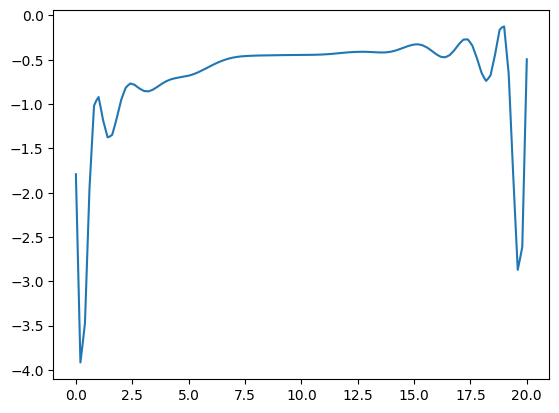

In [7]:
plt.plot(np.linspace(0,t_prot,2*len(opt_control)),delta_t(np.linspace(0,t_prot,2*len(opt_control))))

--> Compute dynamics:


100.0%  100 of  100 [########################################] 00:01:18
Elapsed time: 78.8s
--> Compute dynamics:
100.0%  100 of  100 [########################################] 00:03:30
Elapsed time: 210.1s


/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_41020/2403877591.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


 50.0%  100 of  200 [####################--------------------] 00:08:42

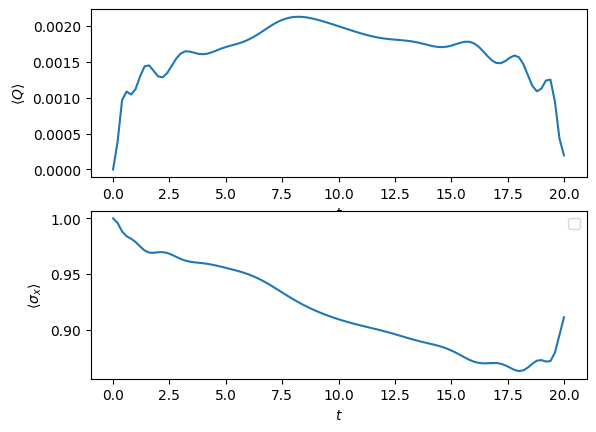

 50.0%  100 of  200 [####################--------------------] 00:11:13

In [46]:
fig,axs=plt.subplots(2)

num_steps=100

# compute dynamics

dynamics=oqupy.compute_dynamics(
process_tensor=processtensor,        
system=system,
initial_state=Rho_0,
start_time=0,
num_steps=num_steps)
t, s_x = dynamics.expectations(op.sigma('x'), real=True)

# compute heats

dynamicscf = oqupy.compute_dynamics(
process_tensor=processtensorcf,        
system=system,
initial_state=Rho_0,
start_time=0,
num_steps=num_steps)

heats=dynamicscf.states.trace(axis1=1,axis2=2).imag/u

axs[0].plot(t,heats,label=t_prot)
axs[0].set_xlabel(r'$t$')
axs[0].set_ylabel(r'$\langle Q \rangle$')
axs[1].plot(t,s_x)
axs[1].set_xlabel(r'$t$')
axs[1].set_ylabel(r'$\langle \sigma_x \rangle$')
plt.legend()
plt.show()

--> Compute correlations:
100.0%  100 of  100 [########################################] 06:01:30
Elapsed time: 21690.3s
(49999, 101)


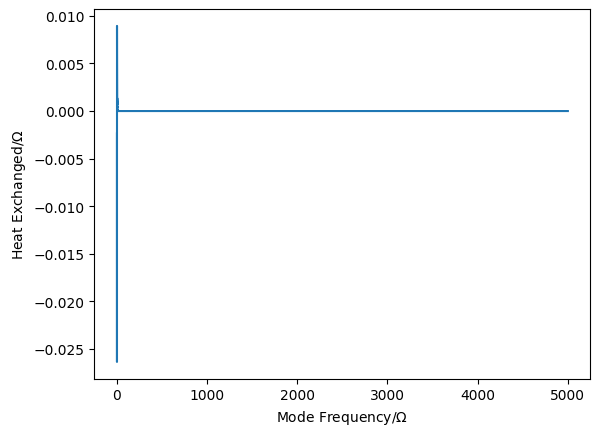

In [10]:
heat_list_osc_f = []
heat_list_osc=[]
freq_list = np.arange(0.1, 5000, 0.1)
for w in freq_list:
    tlist, occ = bath_corr.occupation(w, 0.1,True)
    heat_list_osc_f.append((w * occ)/0.1)
    heat_list_osc.append(w * occ[-1]/0.1)
plt.plot(freq_list, heat_list_osc)
plt.xlabel(r"Mode Frequency$/\Omega$")
plt.ylabel(r"Heat Exchanged$/\Omega$")
print(np.shape(heat_list_osc_f))

Text(0, 0.5, 'Heat Exchanged$/\\Omega$')

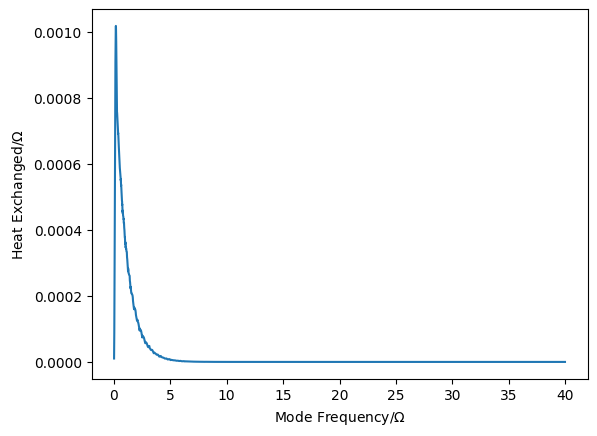

In [52]:
heat_list = []
heat_list_f =[]
freq_list = np.arange(0.01, 100, 0.01)
for w in freq_list:
    tlist, occ = bath_corr.occupation(w, 0.01, True)
    sel = tlist > (tlist[-1] - 2 * np.pi/w)
    sel2 = tlist > (tlist - 2 * np.pi/w)
    energy = occ * w
    period_averaged_energy = np.mean(energy[sel])
    heat_list.append(period_averaged_energy)
    heat_list_f.append(np.mean(energy[sel2]))
plt.plot(freq_list, heat_list)
plt.xlabel(r"Mode Frequency$/\Omega$")
plt.ylabel(r"Heat Exchanged$/\Omega$")

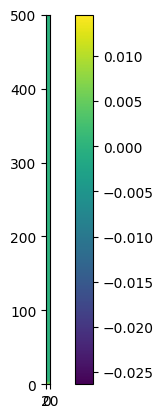

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_54184/3707901415.py:5: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(heat_list_osc_f[:][:100000]),origin='lower', extent=[0,tlist[-1],0,freq_list[5000]], aspect=4)
/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_54184/3707901415.py:5: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(heat_list_osc_f[:][:100000]),origin='lower', extent=[0,tlist[-1],0,freq_list[5000]], aspect=4)


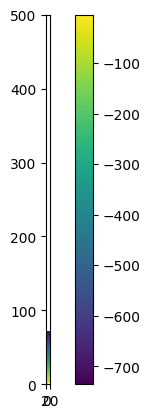

101

In [11]:
plt.imshow(heat_list_osc_f[:][:5000],origin='lower', extent=[0,tlist[-1],0,freq_list[5000]], aspect=4)
plt.colorbar()
plt.show()

plt.imshow(np.log(heat_list_osc_f[:][:100000]),origin='lower', extent=[0,tlist[-1],0,freq_list[5000]], aspect=4)
plt.colorbar()
plt.show()
len(tlist)


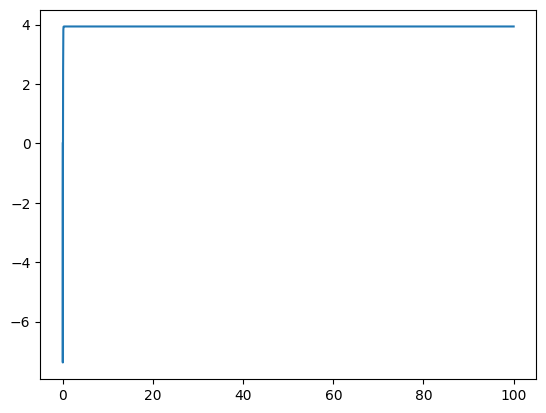

In [12]:
import scipy.integrate as it
test = it.cumulative_trapezoid(heat_list_osc,freq_list,initial=0)/0.001
#test2 = it.cumulative_trapezoid(heat_list,freq_list,initial=0)/0.01
plt.plot(np.linspace(0,100,len(test)),test)

In [13]:
plt.plot(np.linspace(0,100,len(heats)),heats*10,label='h')
plt.plot(np.linspace(0,100,len(test)),test,label='t')
plt.legend()

NameError: name 'heats' is not defined

In [58]:
print(heats[-1])
test[-1]

0.10018834501613004


0.0998248114654604

In [72]:
np.shape(heat_list_osc_f[:][:100])

(100, 101)

In [81]:
freq_list[1000]

10.01